# Tutorial 02 - Moving averages and MACD through decomposition

This tutorial starts from familiar timing strategies-buy and hold, dual moving averages, multi-moving-average alignment, MACD and momentum-then rewrites the signal inputs through De-Time components.

The point is to make the hidden structure explicit: moving averages estimate trend, MACD measures trend acceleration, residual features measure structural overextension, and volume decomposition checks participation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from examples.quant_trading.data import load_sample_goog_ohlcv, market_data_manifest, ohlcv_audit_report
from examples.quant_trading.classic_indicators import macd, sma
from examples.quant_trading.features import walkforward_decompose_ohlcv
from examples.quant_trading.strategy_baselines import make_classic_baseline_weight_grid, run_classical_baselines
from examples.quant_trading.strategy_detime import (
    compare_classical_and_detime,
    make_detime_trend_weight_grid,
    run_detime_trend_baselines,
)
from examples.quant_trading.validation import compare_weight_strategies, write_run_audit

pd.set_option("display.max_columns", 20)
REPORT_DIR = Path("examples/quant_trading/reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)


## 1. Data and feature setup

The same GOOG OHLCV sample is used so that Tutorial 02 connects directly to the feature factory built in Tutorial 01.


In [2]:
ohlcv_single = load_sample_goog_ohlcv(trim_start="2014-01-01")
ticker = ohlcv_single.attrs.get("symbol", "GOOG")
ohlcv = {field: ohlcv_single[[field]].rename(columns={field: ticker}) for field in ["Open", "High", "Low", "Close", "Volume"]}
prices = ohlcv["Close"]
features = walkforward_decompose_ohlcv(
    ohlcv,
    method="STL",
    period="auto",
    period_candidates=(21, 42, 63, 126),
    train_window=252,
    step=21,
    z_window=63,
)
prices.tail()


,GOOG
Date,
2017-12-26,1056.739990
2017-12-27,1049.369995
2017-12-28,1048.140015
2017-12-29,1046.400024
2018-01-02,1065.000000


## 2. Classical baselines first

The baseline layer is intentionally plain: buy-and-hold, dual SMA, MACD, multi-MA alignment and simple momentum. These strategies estimate market state directly from raw close prices.


In [3]:
classical_weights = make_classic_baseline_weight_grid(prices)
classical_table, classical_results = compare_weight_strategies(prices, classical_weights, fee_bps=1.0, slippage_bps=2.0)
display(classical_table[["total_return", "cagr", "sharpe", "max_drawdown", "average_turnover"]].round(4))


,total_return,cagr,sharpe,max_drawdown,average_turnover
strategy,,,,,
buy_hold,0.9207,0.1772,0.8469,-0.1918,0.0000
classic_sma_50_120,0.2176,0.0504,0.3719,-0.2727,0.0129
classic_momentum_63,0.2095,0.0487,0.3515,-0.2227,0.0585
classic_macd_12_26_9,0.1582,0.0374,0.3132,-0.1612,0.0813
classic_sma_20_100,0.0512,0.0126,0.1581,-0.2797,0.0169
classic_multi_ma_20_50_100,0.0367,0.0090,0.1337,-0.2677,0.0248


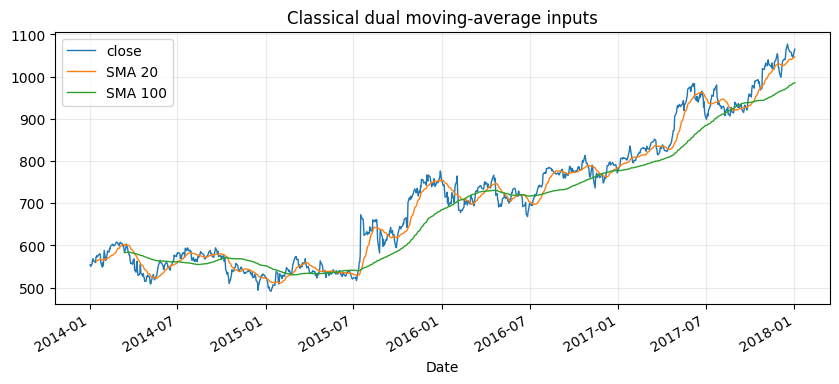

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
prices[ticker].plot(ax=ax, linewidth=1.0, label="close")
sma(prices, 20)[ticker].plot(ax=ax, linewidth=1.0, label="SMA 20")
sma(prices, 100)[ticker].plot(ax=ax, linewidth=1.0, label="SMA 100")
ax.set_title("Classical dual moving-average inputs")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


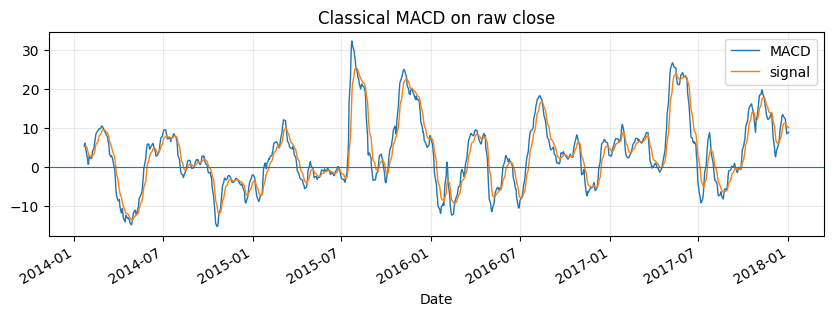

In [5]:
classic_macd = macd(prices, fast=12, slow=26, signal=9)
fig, ax = plt.subplots(figsize=(10, 3))
classic_macd["macd"][ticker].plot(ax=ax, linewidth=1.0, label="MACD")
classic_macd["signal"][ticker].plot(ax=ax, linewidth=1.0, label="signal")
ax.axhline(0, linewidth=0.8)
ax.set_title("Classical MACD on raw close")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


## 3. De-Time rewrites

The De-Time strategy layer keeps the same trading vocabulary but changes the input object. Dual MA and MACD are calculated on the decomposed trend. Cycle and residual features filter entries that are late in the oscillation or structurally overextended. Volume trend and volume residual confirm participation.


In [6]:
detime_weights = make_detime_trend_weight_grid(prices, features)
detime_table, detime_results = compare_weight_strategies(prices, detime_weights, fee_bps=1.0, slippage_bps=2.0)
display(detime_table[["total_return", "cagr", "sharpe", "max_drawdown", "average_turnover"]].round(4))


,total_return,cagr,sharpe,max_drawdown,average_turnover
strategy,,,,,
detime_macd_12_26_9,0.2229,0.0516,0.7077,-0.1404,0.0337
detime_sma_20_100_trend_volume,0.2156,0.0500,0.4191,-0.1896,0.0169
detime_trend_slope,0.2159,0.0501,0.4037,-0.1612,0.0149
detime_trend_cycle_volume,-0.0123,-0.0031,0.0037,-0.1559,0.0149
detime_trend_pullback,-0.0238,-0.0060,-0.0937,-0.0920,0.0069


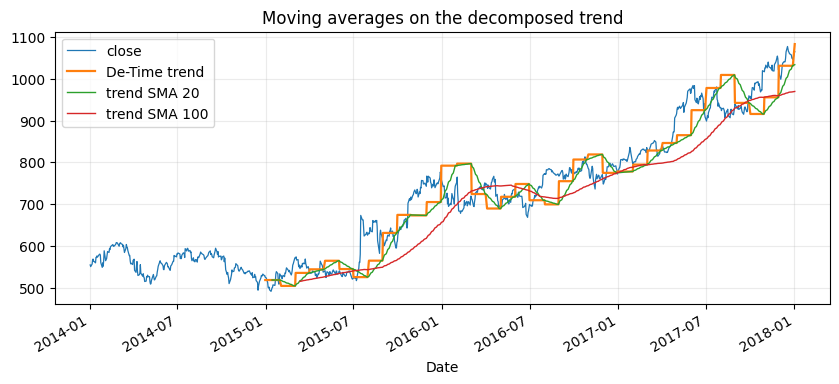

In [7]:
trend_price = np.exp(features["trend"])
fig, ax = plt.subplots(figsize=(10, 4))
prices[ticker].plot(ax=ax, linewidth=0.9, label="close")
trend_price[ticker].plot(ax=ax, linewidth=1.6, label="De-Time trend")
sma(trend_price, 20)[ticker].plot(ax=ax, linewidth=1.0, label="trend SMA 20")
sma(trend_price, 100)[ticker].plot(ax=ax, linewidth=1.0, label="trend SMA 100")
ax.set_title("Moving averages on the decomposed trend")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


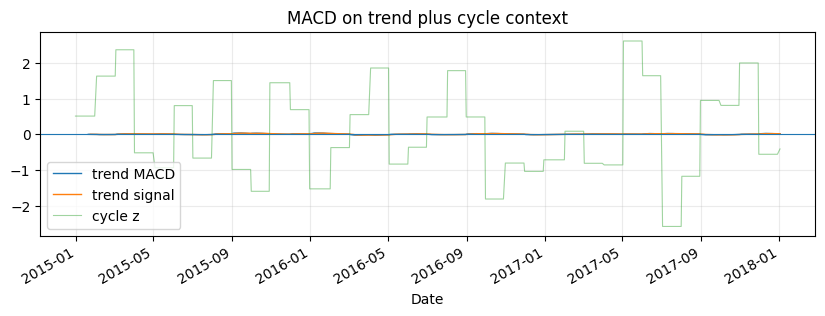

In [8]:
trend_macd = macd(features["trend"], fast=12, slow=26, signal=9)
fig, ax = plt.subplots(figsize=(10, 3))
trend_macd["macd"][ticker].plot(ax=ax, linewidth=1.0, label="trend MACD")
trend_macd["signal"][ticker].plot(ax=ax, linewidth=1.0, label="trend signal")
features["cycle_z"][ticker].plot(ax=ax, linewidth=0.8, alpha=0.45, label="cycle z")
ax.axhline(0, linewidth=0.8)
ax.set_title("MACD on trend plus cycle context")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


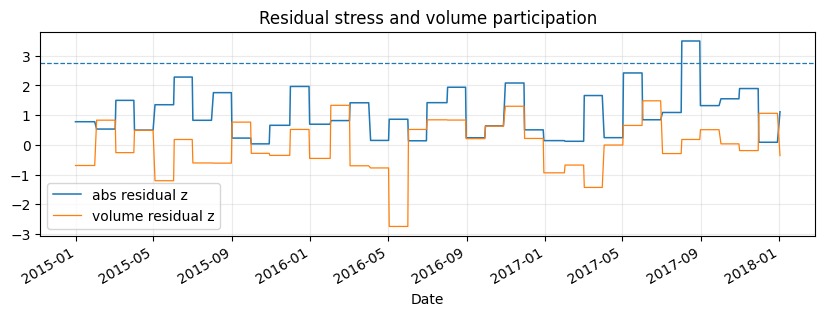

In [9]:
fig, ax = plt.subplots(figsize=(10, 3))
features["residual_abs_z"][ticker].plot(ax=ax, linewidth=1.1, label="abs residual z")
features["volume_residual_z"][ticker].plot(ax=ax, linewidth=0.9, label="volume residual z")
ax.axhline(2.75, linestyle="--", linewidth=0.9)
ax.set_title("Residual stress and volume participation")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


## 4. Compare strategy curves

The comparison keeps every baseline visible, then adds the decomposition-aware strategies below the same cost assumptions.


In [10]:
comparison = compare_classical_and_detime(
    run_classical_baselines(prices, fee_bps=1.0, slippage_bps=2.0),
    run_detime_trend_baselines(prices, features, fee_bps=1.0, slippage_bps=2.0),
)
display(comparison[["strategy_group", "total_return", "cagr", "sharpe", "max_drawdown", "average_turnover"]].round(4))


,strategy_group,total_return,cagr,sharpe,max_drawdown,average_turnover
strategy,,,,,,
buy_hold,classical,0.9207,0.1772,0.8469,-0.1918,0.0000
detime_macd_12_26_9,detime,0.2229,0.0516,0.7077,-0.1404,0.0337
detime_sma_20_100_trend_volume,detime,0.2156,0.0500,0.4191,-0.1896,0.0169
detime_trend_slope,detime,0.2159,0.0501,0.4037,-0.1612,0.0149
classic_sma_50_120,classical,0.2176,0.0504,0.3719,-0.2727,0.0129
classic_momentum_63,classical,0.2095,0.0487,0.3515,-0.2227,0.0585
classic_macd_12_26_9,classical,0.1582,0.0374,0.3132,-0.1612,0.0813
classic_sma_20_100,classical,0.0512,0.0126,0.1581,-0.2797,0.0169
classic_multi_ma_20_50_100,classical,0.0367,0.0090,0.1337,-0.2677,0.0248


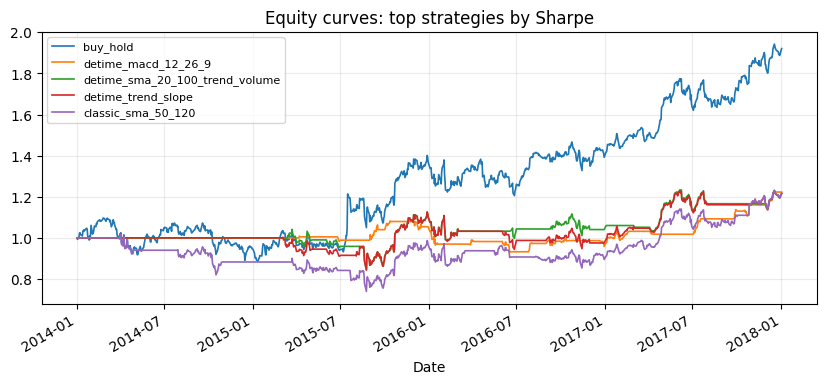

In [11]:
all_results = {**classical_results, **detime_results}
leaders = comparison.head(5).index.tolist()
fig, ax = plt.subplots(figsize=(10, 4))
for name in leaders:
    all_results[name].equity.plot(ax=ax, linewidth=1.2, label=name)
ax.set_title("Equity curves: top strategies by Sharpe")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.25)
plt.show()


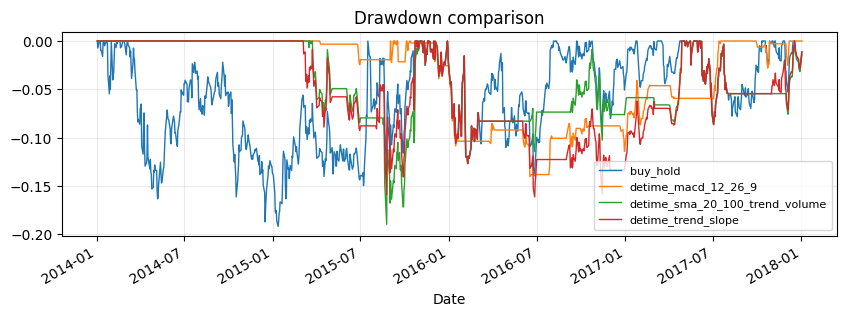

In [12]:
fig, ax = plt.subplots(figsize=(10, 3))
for name in leaders[:4]:
    dd = all_results[name].equity / all_results[name].equity.cummax() - 1.0
    dd.plot(ax=ax, linewidth=1.0, label=name)
ax.set_title("Drawdown comparison")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.25)
plt.show()


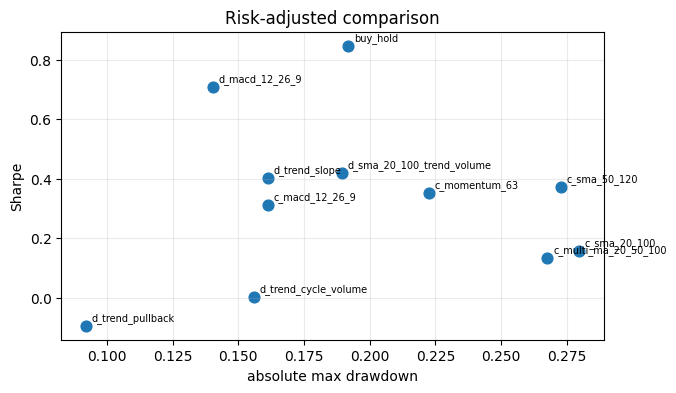

In [13]:
plot_table = comparison.copy()
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(plot_table["max_drawdown"].abs(), plot_table["sharpe"], s=60)
for name, row in plot_table.iterrows():
    ax.annotate(name.replace("classic_", "c_").replace("detime_", "d_"), (abs(row["max_drawdown"]), row["sharpe"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("absolute max drawdown")
ax.set_ylabel("Sharpe")
ax.set_title("Risk-adjusted comparison")
ax.grid(True, alpha=0.25)
plt.show()


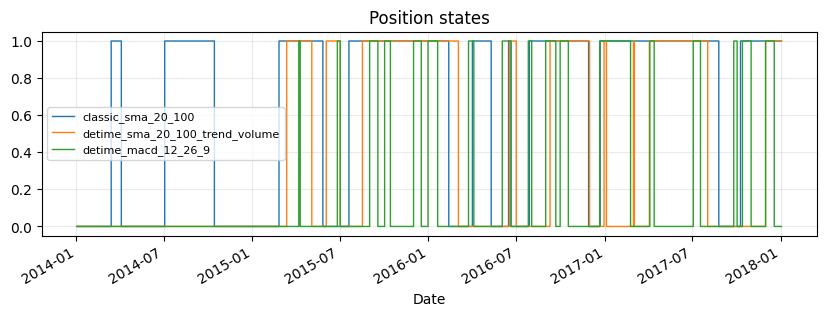

In [14]:
fig, ax = plt.subplots(figsize=(10, 3))
for name in ["classic_sma_20_100", "detime_sma_20_100_trend_volume", "detime_macd_12_26_9"]:
    weights = (classical_weights | detime_weights)[name]
    weights[ticker].plot(ax=ax, drawstyle="steps-post", linewidth=1.0, label=name)
ax.set_title("Position states")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.25)
plt.show()


In [15]:
paths = write_run_audit(
    REPORT_DIR,
    data_manifest=market_data_manifest(
        tickers=[ticker],
        start=str(prices.index.min().date()),
        end=str(prices.index.max().date()),
        interval="1d",
        source=ohlcv_single.attrs.get("source", "bundled historical OHLCV sample"),
    ),
    audit=ohlcv_audit_report(ohlcv),
    strategy_stats=comparison,
    prefix="column_02",
)
display(pd.DataFrame({"artifact": list(paths), "path": [str(p) for p in paths.values()]}))


,artifact,path
0,manifest,examples\quant_trading\reports\column_02_marke...
1,data_audit,examples\quant_trading\reports\column_02_data_...
2,strategy_stats,examples\quant_trading\reports\column_02_strat...
3,run_manifest,examples\quant_trading\reports\column_02_run_m...
